DATA LOADING

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [ ]:
for col in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].value_counts())


State (8 unique values):
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District (10 unique values):
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop (8 unique values):
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season (3 unique values):
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method (4 unique values):
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


Duplicate records


In [ ]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated Farm_ID:", df['Farm_ID'].duplicated().sum())

Fully duplicated rows: 0
Duplicated Farm_ID: 0


Checking Numerics Ranges --OUTLIERS

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

outlier_summary = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, round(lower,2), round(upper,2), n_outliers, round(n_outliers/len(df)*100,2)])

outlier_df = pd.DataFrame(outlier_summary, columns=['Column','Lower_bound','Upper_bound','Outlier_count','Outlier_pct'])
outlier_df.sort_values('Outlier_pct', ascending=False)

,Column,Lower_bound,Upper_bound,Outlier_count,Outlier_pct
18,Profit_INR,-696111.00,763567.00,404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.63,5.52,302,7.55
19,Water_Used_m3,-6072.75,16171.25,276,6.90
17,Revenue_INR,-736519.00,1780911.00,240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


In [ ]:
print(df['Yield_Tonnes_Ha'].describe())
print("\nTop 10 highest yield records:")
df.nlargest(10, 'Yield_Tonnes_Ha')[['Farm_ID','Crop','Season','Farm_Area_Hectares','Yield_Tonnes_Ha','Production_Tonnes']]

count    3968.000000
mean        5.270595
std        13.361398
min         0.300000
25%         1.050000
50%         1.740000
75%         2.840000
max       101.440000
Name: Yield_Tonnes_Ha, dtype: float64

Top 10 highest yield records:


,Farm_ID,Crop,Season,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes
1715,SF11716,Sugarcane,Kharif,6.32,101.44,641.10
3423,SF13424,Sugarcane,Kharif,14.87,95.79,1424.40
3525,SF13526,Sugarcane,Rabi,6.96,93.13,648.18
1464,SF11465,Sugarcane,Kharif,7.65,91.98,703.65
3523,SF13524,Sugarcane,Kharif,0.82,91.46,75.00
2782,SF12783,Sugarcane,Rabi,5.72,91.32,522.35
644,SF10645,Sugarcane,Kharif,7.48,89.34,668.26
2847,SF12848,Sugarcane,Kharif,7.66,87.76,672.24
357,SF10358,Sugarcane,Rabi,14.74,84.75,1249.21
1178,SF11179,Sugarcane,Kharif,6.38,83.79,534.58


HANDLING MISSING VALUES

In [ ]:
df_clean = df.copy()

# Rainfall & Soil Moisture: impute using the median WITHIN each Season, since these
# are naturally season-dependent — a global median would blur real seasonal differences.
for col in ['Rainfall_mm', 'Soil_Moisture_pct']:
    df_clean[col] = df_clean.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

# Yield: impute using the median WITHIN each (Crop, Season) group, since yield
# depends heavily on both crop type and season.
df_clean['Yield_Tonnes_Ha'] = df_clean.groupby(['Crop','Season'])['Yield_Tonnes_Ha'] \
                                       .transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df_clean.isnull().sum().sum())

Remaining missing values: 0


In [ ]:
q1, q3 = df_clean['Yield_Tonnes_Ha'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_cap = q3 + 1.5*iqr

n_capped = (df_clean['Yield_Tonnes_Ha'] > upper_cap).sum()
df_clean['Yield_Tonnes_Ha'] = df_clean['Yield_Tonnes_Ha'].clip(upper=upper_cap)

print(f"Capped {n_capped} extreme yield values at {upper_cap:.2f} t/ha")
print(df_clean['Yield_Tonnes_Ha'].describe())

Capped 304 extreme yield values at 5.52 t/ha
count    4000.000000
mean        2.102439
std         1.424417
min         0.300000
25%         1.050000
50%         1.740000
75%         2.840000
max         5.525000
Name: Yield_Tonnes_Ha, dtype: float64


In [ ]:
# Profit margin as a % of revenue — easier to compare across farms of different scale
df_clean['Profit_Margin_pct'] = (df_clean['Profit_INR'] / df_clean['Revenue_INR']) * 100

# Cost per tonne produced — efficiency metric
df_clean['Cost_per_Tonne'] = df_clean['Total_Cost_INR'] / df_clean['Production_Tonnes'].replace(0, np.nan)

# Flag: was the farm profitable?
df_clean['Is_Profitable'] = df_clean['Profit_INR'] > 0

print(df_clean[['Profit_Margin_pct','Cost_per_Tonne','Is_Profitable']].describe(include='all'))

        Profit_Margin_pct  Cost_per_Tonne Is_Profitable
count         4000.000000     4000.000000          4000
unique                NaN             NaN             2
top                   NaN             NaN          True
freq                  NaN             NaN          2034
mean           -45.492178    55624.858332           NaN
std            158.085472    54260.608703           NaN
min          -1461.851219      568.357511           NaN
25%            -60.192762    23032.641975           NaN
50%              1.146236    37897.601738           NaN
75%             32.885876    64153.096089           NaN
max             85.921220   296805.128205           NaN


In [ ]:
print("Final cleaned dataset shape:", df_clean.shape)
df_clean.head()

Final cleaned dataset shape: (4000, 31)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Cost_per_Tonne,Is_Profitable
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,23700,42662,30810,-11852,237,5.485,55.3,-38.468030,32816.923077,False
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,20613,492351,40401,-451950,4953,0.396,49.9,-1118.660429,251199.489796,False
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,75283,315210,190466,-124744,1275,1.984,33.7,-65.494104,124588.932806,False
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,24244,296444,200740,-95704,3834,2.160,50.6,-47.675600,35802.415459,False
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,20818,337959,193607,-144352,3287,2.829,32.3,-74.559288,36339.677419,False


Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


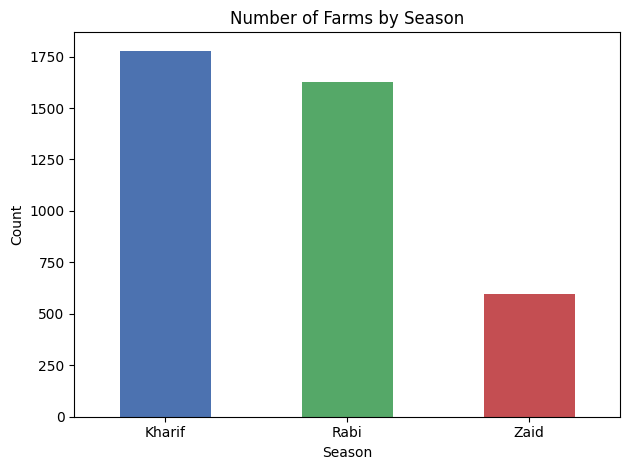

In [ ]:
season_counts = df_clean['Season'].value_counts()
print(season_counts)

fig, ax = plt.subplots()
season_counts.plot(kind='bar', color=['#4C72B0','#55A868','#C44E52'], ax=ax)
ax.set_title('Number of Farms by Season')
ax.set_xlabel('Season'); ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
env_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_Moisture_pct']
season_env = df_clean.groupby('Season')[env_cols].mean().round(2)
season_env

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.11,28.45,71.81,6.79,31.20
Rabi,435.94,23.49,57.89,7.59,24.05
Zaid,299.12,31.04,52.01,8.18,19.17


/tmp/ipykernel_2198/369430555.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_2198/369430555.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_2198/369430555.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_2198/369430555.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wi

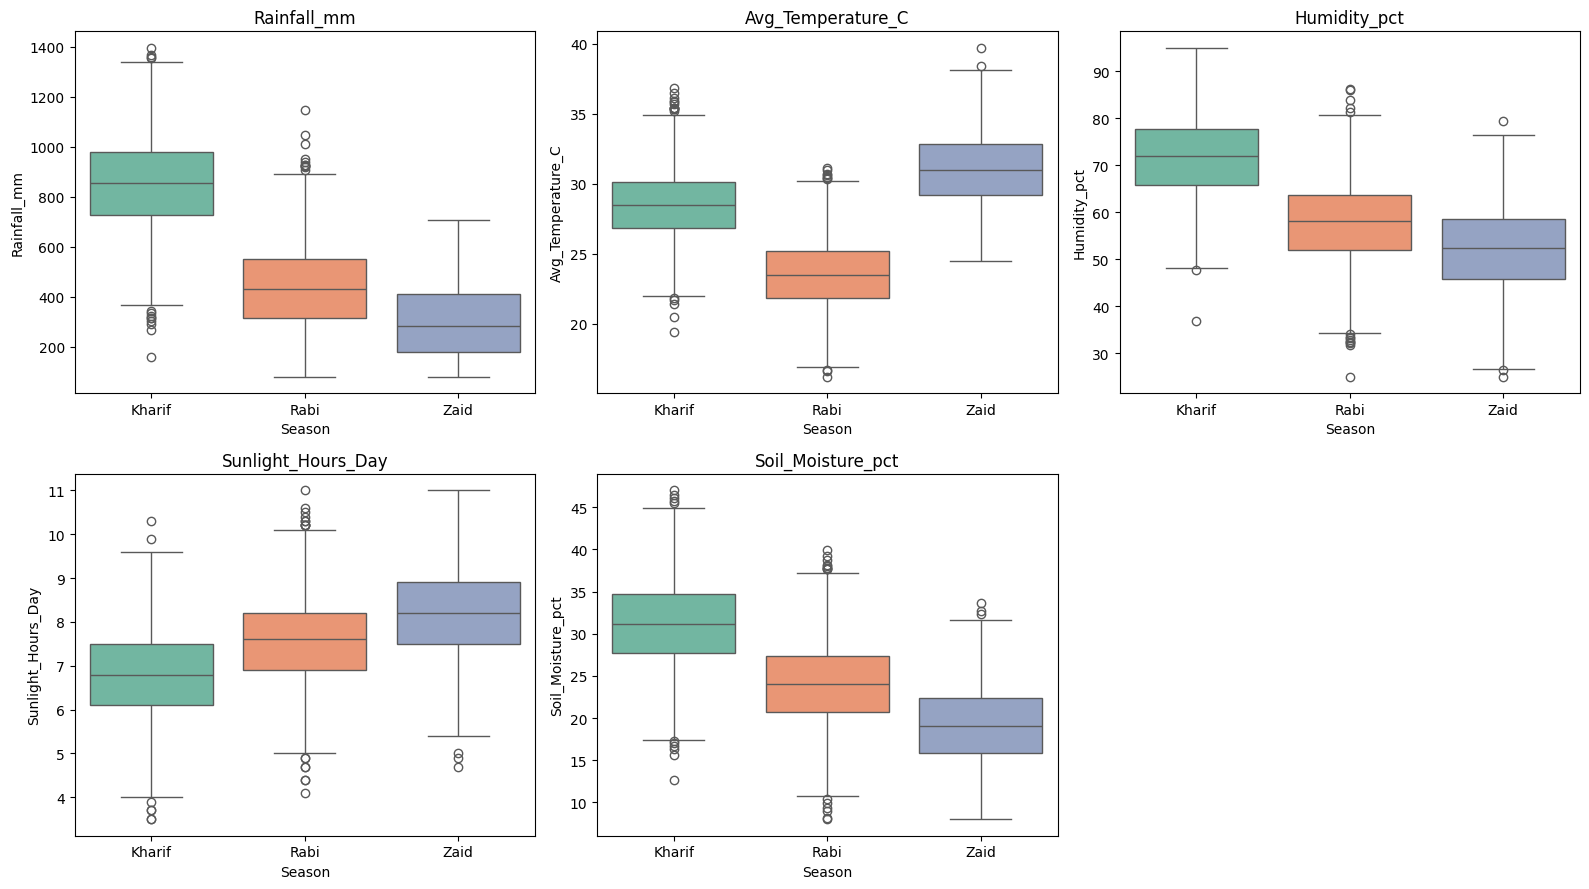

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(env_cols):
    sns.boxplot(data=df_clean, x='Season', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
perf_cols = ['Yield_Tonnes_Ha','Production_Tonnes','Total_Cost_INR','Revenue_INR','Profit_INR','Profit_Margin_pct']
season_perf = df_clean.groupby('Season')[perf_cols].mean().round(2)
season_perf

,Yield_Tonnes_Ha,Production_Tonnes,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,,,
Kharif,2.26,46.31,531804.41,710719.06,178914.65,-38.64
Rabi,2.04,41.49,513836.58,601526.05,87689.47,-44.27
Zaid,1.81,38.89,543976.73,519171.90,-24804.82,-69.35


/tmp/ipykernel_2198/2743817109.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y=col, ax=axes[i], palette='Set2', estimator=np.mean, errorbar='sd')
/tmp/ipykernel_2198/2743817109.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y=col, ax=axes[i], palette='Set2', estimator=np.mean, errorbar='sd')
/tmp/ipykernel_2198/2743817109.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y=col, ax=axes[i], palette='Set2', estimator=np.mean, errorbar='sd')
/tmp/ipyke

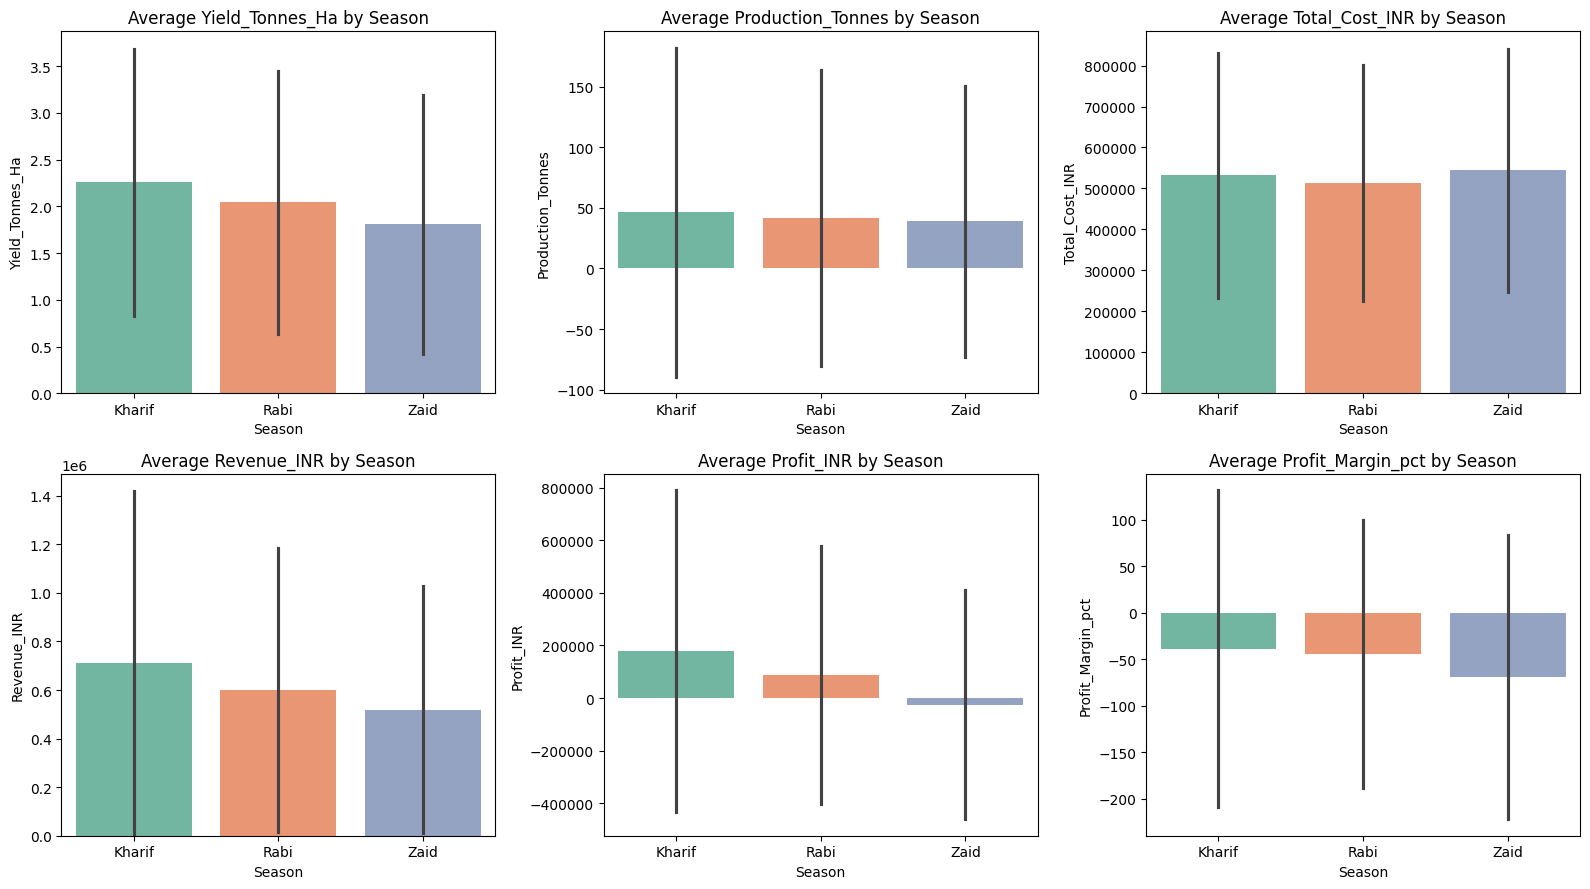

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(perf_cols):
    sns.barplot(data=df_clean, x='Season', y=col, ax=axes[i], palette='Set2', estimator=np.mean, errorbar='sd')
    axes[i].set_title(f'Average {col} by Season')
plt.tight_layout()
plt.show()

        Loss-making %  Profitable %
Season                             
Kharif           42.2          57.8
Rabi             51.1          48.9
Zaid             64.5          35.5


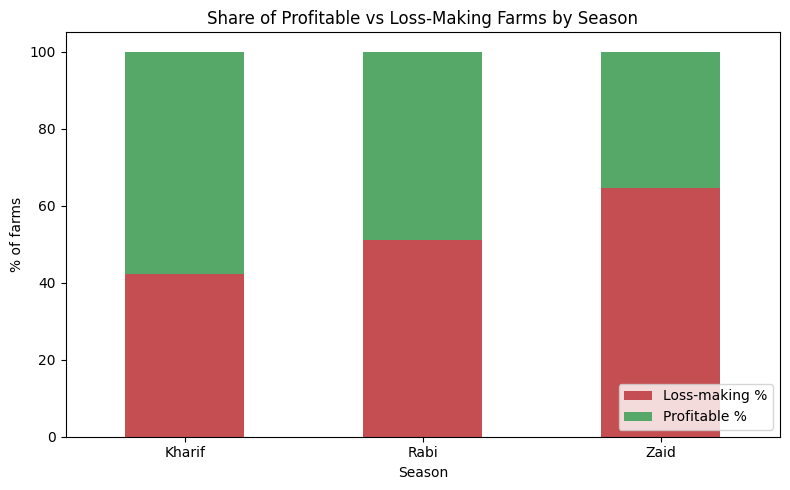

In [ ]:
profitability = pd.crosstab(df_clean['Season'], df_clean['Is_Profitable'], normalize='index') * 100
profitability.columns = ['Loss-making %','Profitable %']
print(profitability.round(1))

profitability.plot(kind='bar', stacked=True, figsize=(8,5), color=['#C44E52','#55A868'])
plt.title('Share of Profitable vs Loss-Making Farms by Season')
plt.ylabel('% of farms'); plt.xlabel('Season')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
resource_cols = ['Water_Used_m3','Water_Efficiency_t_per_1000m3','Fertilizer_kg_ha','Pesticide_Litre_ha']
season_resources = df_clean.groupby('Season')[resource_cols].mean().round(2)
season_resources

,Water_Used_m3,Water_Efficiency_t_per_1000m3,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,,
Kharif,6102.20,5.89,187.08,5.08
Rabi,5846.99,5.19,185.41,5.02
Zaid,6419.89,4.41,184.64,5.17


/tmp/ipykernel_2198/1384538735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_2198/1384538735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_2198/1384538735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_2198/1384538735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated an

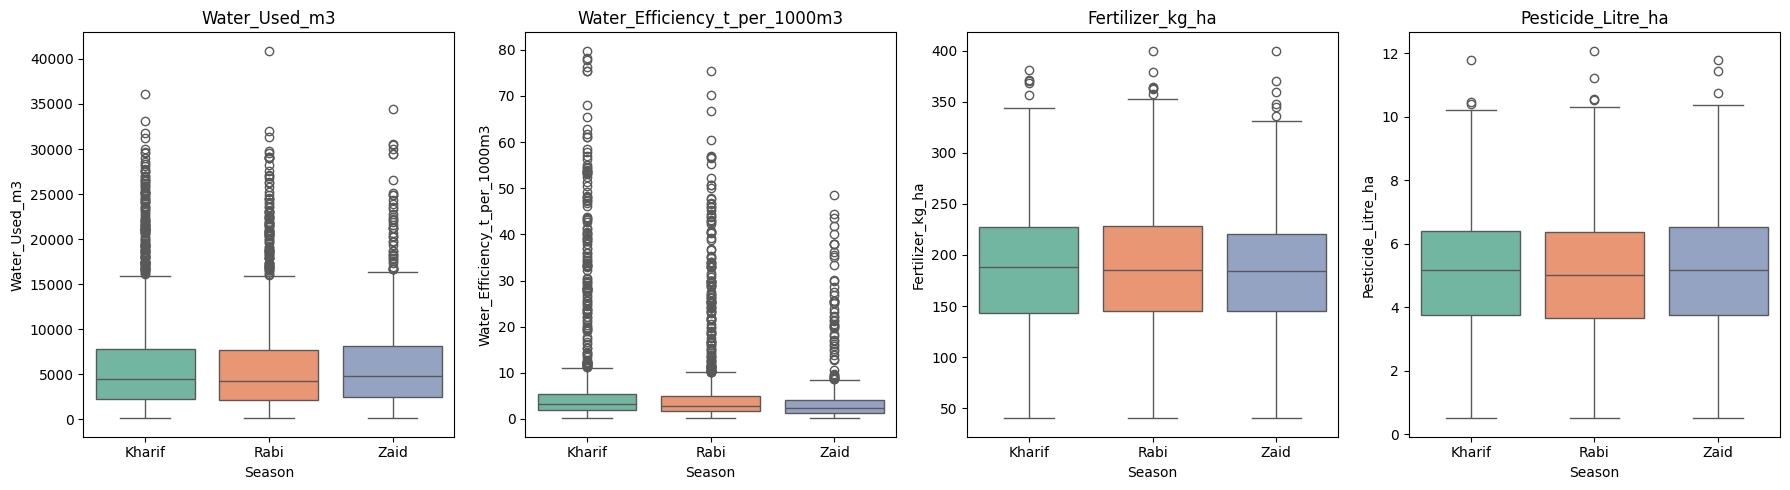

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18,5))
for i, col in enumerate(resource_cols):
    sns.boxplot(data=df_clean, x='Season', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
crop_season = pd.crosstab(df_clean['Crop'], df_clean['Season'])
crop_season

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


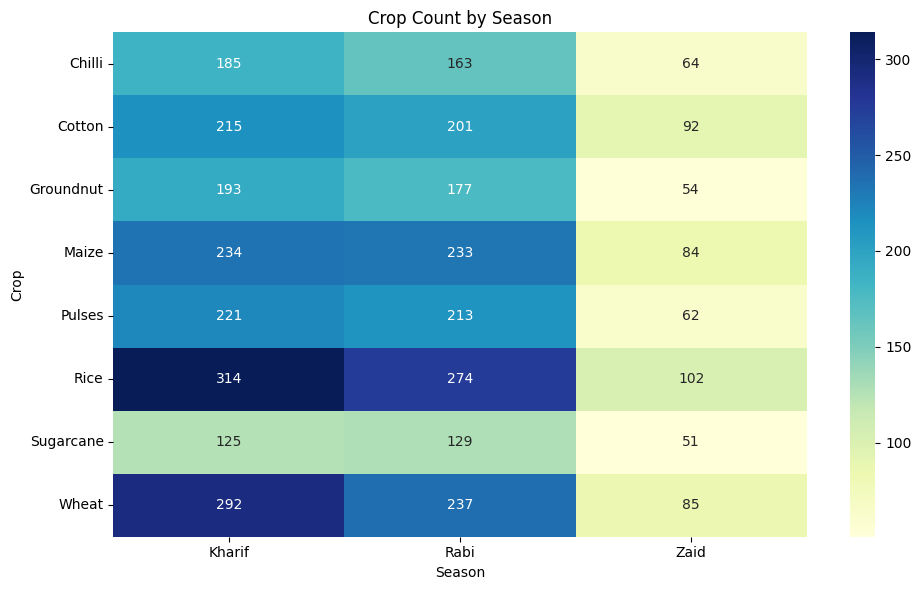

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(crop_season, annot=True, fmt='d', cmap='YlGnBu', ax=ax)
ax.set_title('Crop Count by Season')
plt.tight_layout()
plt.show()

In [ ]:
crop_season_yield = df_clean.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean').round(2)
crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.96,2.62,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,5.46,5.46,5.44
Wheat,2.26,2.06,1.75


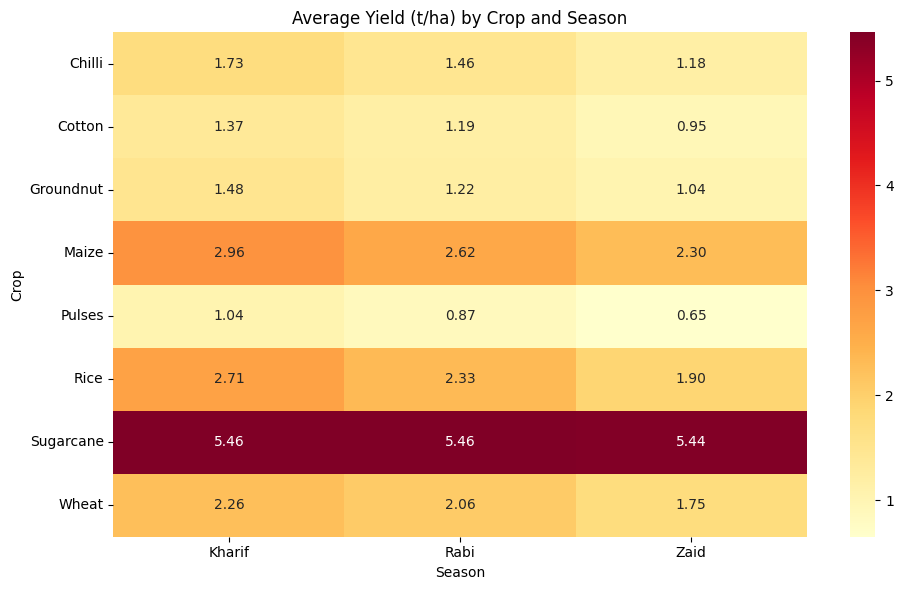

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(crop_season_yield, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_title('Average Yield (t/ha) by Crop and Season')
plt.tight_layout()
plt.show()

In [ ]:
irrigation_season = df_clean.pivot_table(index='Irrigation_Method', columns='Season',
                                          values='Profit_INR', aggfunc='mean').round(0)
irrigation_season

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,317222.0,187843.0,21292.0
Flood,133374.0,58825.0,-69787.0
Rainfed,158974.0,45232.0,-79467.0
Sprinkler,116880.0,76502.0,57909.0


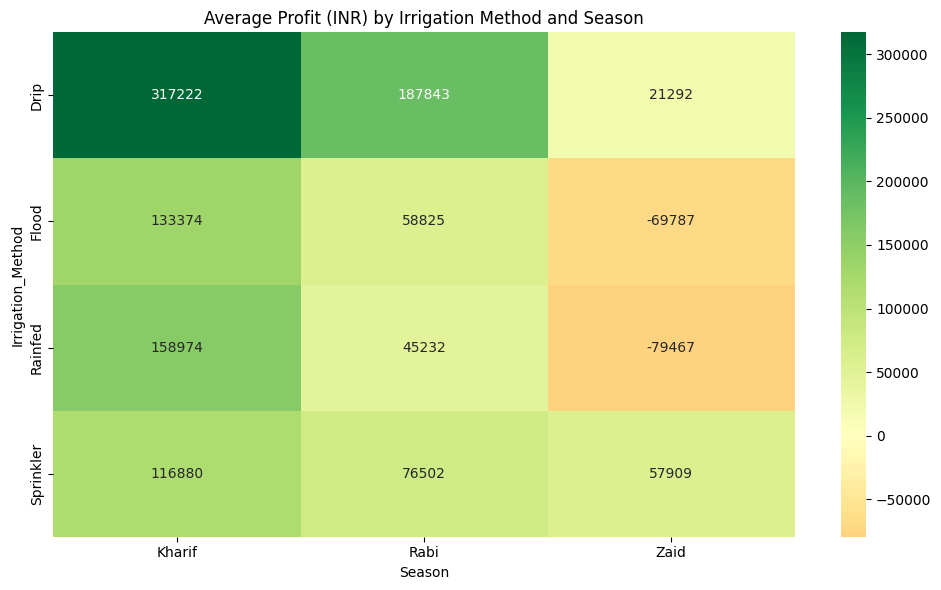

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(irrigation_season, annot=True, fmt='.0f', cmap='RdYlGn', ax=ax, center=0)
ax.set_title('Average Profit (INR) by Irrigation Method and Season')
plt.tight_layout()
plt.show()

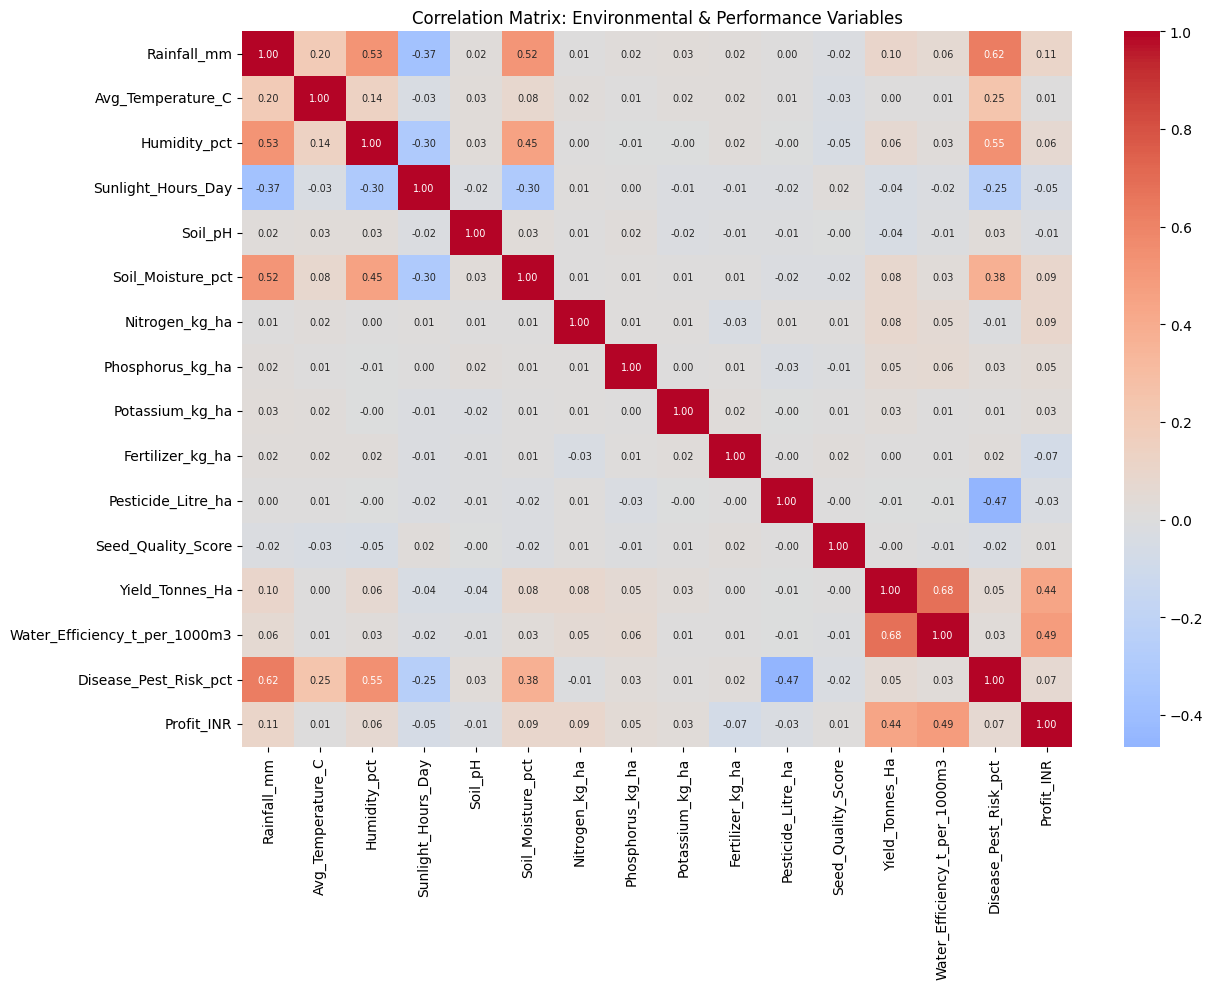

In [ ]:
corr_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH',
             'Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha',
             'Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score',
             'Yield_Tonnes_Ha','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct','Profit_INR']

corr = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, annot_kws={'size':7})
ax.set_title('Correlation Matrix: Environmental & Performance Variables')
plt.tight_layout()
plt.show()

In [ ]:
print("Strongest correlations with Yield_Tonnes_Ha:")
print(corr['Yield_Tonnes_Ha'].sort_values(ascending=False))
print("\nStrongest correlations with Profit_INR:")
print(corr['Profit_INR'].sort_values(ascending=False))

Strongest correlations with Yield_Tonnes_Ha:
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.681619
Profit_INR                       0.441481
Rainfall_mm                      0.100351
Soil_Moisture_pct                0.083046
Nitrogen_kg_ha                   0.081738
Humidity_pct                     0.064235
Phosphorus_kg_ha                 0.053051
Disease_Pest_Risk_pct            0.051663
Potassium_kg_ha                  0.031688
Fertilizer_kg_ha                 0.003084
Avg_Temperature_C                0.001659
Seed_Quality_Score              -0.001393
Pesticide_Litre_ha              -0.005063
Soil_pH                         -0.038480
Sunlight_Hours_Day              -0.042469
Name: Yield_Tonnes_Ha, dtype: float64

Strongest correlations with Profit_INR:
Profit_INR                       1.000000
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.441481
Rainfall_mm                      0.106117
Soil_Moisture_pct                0.0

In [ ]:

from scipy.stats import f_oneway, pearsonr

df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

# quick clean
df['Rainfall_mm'] = df.groupby('Season')['Rainfall_mm'].transform(lambda x: x.fillna(x.median()))
df['Soil_Moisture_pct'] = df.groupby('Season')['Soil_Moisture_pct'].transform(lambda x: x.fillna(x.median()))
df['Yield_Tonnes_Ha'] = df.groupby(['Crop','Season'])['Yield_Tonnes_Ha'].transform(lambda x: x.fillna(x.median()))
cap = df['Yield_Tonnes_Ha'].quantile(.75) + 1.5*(df['Yield_Tonnes_Ha'].quantile(.75)-df['Yield_Tonnes_Ha'].quantile(.25))
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].clip(upper=cap)
df['Is_Profitable'] = df['Profit_INR'] > 0
df.isnull().sum().sum()

np.int64(0)

ANSWERING THE 12 QUESTIONS MENTIONED

In [ ]:
# Q1. How does agricultural performance vary across seasons?
df.groupby('Season')[['Yield_Tonnes_Ha','Total_Cost_INR','Revenue_INR','Profit_INR']].mean().round(2)

,Yield_Tonnes_Ha,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,
Kharif,2.26,531804.41,710719.06,178914.65
Rabi,2.04,513836.58,601526.05,87689.47
Zaid,1.81,543976.73,519171.90,-24804.82


In [ ]:
# Q2. What major seasonal patterns can be observed?
df.groupby('Season')[['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Yield_Tonnes_Ha']].mean().round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Yield_Tonnes_Ha
Season,,,,
Kharif,852.11,28.45,71.81,2.26
Rabi,435.94,23.49,57.89,2.04
Zaid,299.12,31.04,52.01,1.81


In [ ]:
# Q3. Which characteristics change between seasons?
cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH',
        'Soil_Moisture_pct','Yield_Tonnes_Ha','Total_Cost_INR','Profit_INR','Disease_Pest_Risk_pct']
df.groupby('Season')[cols].mean().round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Yield_Tonnes_Ha,Total_Cost_INR,Profit_INR,Disease_Pest_Risk_pct
Season,,,,,,,,,,
Kharif,852.11,28.45,71.81,6.79,6.73,31.20,2.26,531804.41,178914.65,54.47
Rabi,435.94,23.49,57.89,7.59,6.67,24.05,2.04,513836.58,87689.47,40.48
Zaid,299.12,31.04,52.01,8.18,6.69,19.17,1.81,543976.73,-24804.82,38.22


In [ ]:
# Q4. What differences exist between agricultural activities in different seasons?
pd.crosstab(df['Crop'], df['Season'])

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


In [ ]:
# Q5. Are there noticeable variations in resource usage across seasons?
df.groupby('Season')[['Water_Used_m3','Water_Efficiency_t_per_1000m3','Fertilizer_kg_ha','Pesticide_Litre_ha']].mean().round(2)

,Water_Used_m3,Water_Efficiency_t_per_1000m3,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,,
Kharif,6102.20,5.89,187.08,5.08
Rabi,5846.99,5.19,185.41,5.02
Zaid,6419.89,4.41,184.64,5.17


In [ ]:
# Q6. Are there relationships between seasonal environmental conditions and agricultural performance?
env_perf = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct','Yield_Tonnes_Ha','Profit_INR']
df[env_perf].corr().round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Yield_Tonnes_Ha,Profit_INR
Rainfall_mm,1.00,0.20,0.53,0.52,0.10,0.11
Avg_Temperature_C,0.20,1.00,0.14,0.08,0.00,0.01
Humidity_pct,0.53,0.14,1.00,0.45,0.06,0.06
Soil_Moisture_pct,0.52,0.08,0.45,1.00,0.08,0.09
Yield_Tonnes_Ha,0.10,0.00,0.06,0.08,1.00,0.44
Profit_INR,0.11,0.01,0.06,0.09,0.44,1.00


In [ ]:
# Q7. How do economic outcomes vary across seasons?
df.groupby('Season')[['Total_Cost_INR','Revenue_INR','Profit_INR']].mean().round(2)
df.groupby('Season')['Is_Profitable'].mean().mul(100).round(1)

,Is_Profitable
Season,
Kharif,57.8
Rabi,48.9
Zaid,35.5


In [ ]:
# Q8. Are some seasonal patterns consistent across different regions or categories?
df.pivot_table(index='State', columns='Season', values='Profit_INR', aggfunc='mean').round(0)

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


In [ ]:
# Q9. Are there unusual or unexpected seasonal patterns?
print("Loss-making farms overall:", round((df['Profit_INR']<0).mean()*100,1), "%")
print("Loss-making farms by season:")
print(df.groupby('Season')['Is_Profitable'].apply(lambda x: round((1-x.mean())*100,1)))

Loss-making farms overall: 49.2 %
Loss-making farms by season:
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Is_Profitable, dtype: float64


In [ ]:
# Q10. What insights can be derived from the observed seasonal differences?
df.groupby('Season')[['Yield_Tonnes_Ha','Profit_INR','Disease_Pest_Risk_pct']].mean().round(2)

,Yield_Tonnes_Ha,Profit_INR,Disease_Pest_Risk_pct
Season,,,
Kharif,2.26,178914.65,54.47
Rabi,2.04,87689.47,40.48
Zaid,1.81,-24804.82,38.22


In [ ]:
# Q11. What conclusions can reasonably be drawn from the available data? (statistical significance)
for col in ['Yield_Tonnes_Ha','Profit_INR','Total_Cost_INR']:
    groups = [df[df['Season']==s][col] for s in df['Season'].unique()]
    f, p = f_oneway(*groups)
    print(col, "p =", round(p,4), "-> significant" if p<0.05 else "-> not significant")

r, p = pearsonr(df['Rainfall_mm'], df['Yield_Tonnes_Ha'])
print("Rainfall vs Yield correlation r =", round(r,3), "p =", round(p,4))

Yield_Tonnes_Ha p = 0.0 -> significant
Profit_INR p = 0.0 -> significant
Total_Cost_INR p = 0.0584 -> not significant
Rainfall vs Yield correlation r = 0.1 p = 0.0


In [ ]:
# Q12. How could the findings support better seasonal agricultural planning?
best_profit_season = df.groupby('Season')['Profit_INR'].mean().idxmax()
worst_profit_season = df.groupby('Season')['Profit_INR'].mean().idxmin()
best_irrigation = df.pivot_table(index='Irrigation_Method', columns='Season', values='Profit_INR', aggfunc='mean')
highest_risk_season = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().idxmax()

print("Strongest season:", best_profit_season)
print("Weakest season (needs support):", worst_profit_season)
print("Highest disease/pest risk season:", highest_risk_season)
best_irrigation.round(0)

Strongest season: Kharif
Weakest season (needs support): Zaid
Highest disease/pest risk season: Kharif


Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,317222.0,187843.0,21292.0
Flood,133374.0,58825.0,-69787.0
Rainfed,158974.0,45232.0,-79467.0
Sprinkler,116880.0,76502.0,57909.0


In [ ]:
summary = df_clean.groupby('Season').agg(
    Farms=('Farm_ID','count'),
    Avg_Rainfall_mm=('Rainfall_mm','mean'),
    Avg_Temp_C=('Avg_Temperature_C','mean'),
    Avg_Yield_t_ha=('Yield_Tonnes_Ha','mean'),
    Avg_Cost_INR=('Total_Cost_INR','mean'),
    Avg_Revenue_INR=('Revenue_INR','mean'),
    Avg_Profit_INR=('Profit_INR','mean'),
    Pct_Profitable=('Is_Profitable', lambda x: (x.mean()*100)),
    Avg_Water_Used_m3=('Water_Used_m3','mean'),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct','mean')
).round(2)
summary

,Farms,Avg_Rainfall_mm,Avg_Temp_C,Avg_Yield_t_ha,Avg_Cost_INR,Avg_Revenue_INR,Avg_Profit_INR,Pct_Profitable,Avg_Water_Used_m3,Avg_Disease_Risk_pct
Season,,,,,,,,,,
Kharif,1779,852.11,28.45,2.26,531804.41,710719.06,178914.65,57.79,6102.20,54.47
Rabi,1627,435.94,23.49,2.04,513836.58,601526.05,87689.47,48.86,5846.99,40.48
Zaid,594,299.12,31.04,1.81,543976.73,519171.90,-24804.82,35.52,6419.89,38.22
